# Topological MQA (TMQA) 3: `ibm_miami`
This is the third notebook for Topological MQA series. We will run the same process on `ibm_miami`, which is the real hardware. Of course, it also has 120 qubits with 10 x 12 arrangement.

In [ ]:
# If you want to use the real QPU, set up the global variable for your API tokens.
# If you want to use the data from ibm_miami in this repository, move on.
IBM_RUNTIME_TOKEN = ""
INSTANCE = ""
NAME = ""

In [23]:
# Run the setup
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from qiskit_device_benchmarking.bench_code.mrb import (
    MirrorQATopo,
    QuantumAwesomeness,
)
import os
import random
import pathlib
import json
from collections import defaultdict
import pickle

# Set up seed
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
QiskitRuntimeService.save_account(
    token=IBM_RUNTIME_TOKEN,
    instance=INSTANCE,
    name="", # Put your account name
    set_as_default=True,  # Optional
    overwrite=True,
)

In [4]:
service = QiskitRuntimeService()

In [5]:
backend = service.backend("ibm_miami")

### Import Helper functions

Below cells are for helper functions to:
1. Save the ongoing experiment as `.pkl` to the disk, so if the kernel crashes or the laptop goes to Sleep Mode, a researcher doesn't need to execute the entire experiment from the beginning again.
2. Analysis & Terminal printing: Definition of a *bot*, calculation of the `P(pairs)` and `P(topo)`.

In [10]:
# Part 1: Prepare .pkl
ckpt_dir = pathlib.Path("topo_ckpt")
ckpt_dir.mkdir(exist_ok=True)

In [11]:
# Part 2: Experiment side
# To deduct the mode for TopoSampler
def get_topo_mode(topo_full, fake_qubits):
    """f2f if the fake qubits paired together (or stayed unpaired); 
    f2g otherwise."""
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return "f2f"
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return "f2f"
    return "f2g"

In [12]:
# Calculates the MI from the result
def extract_mi(exp, rb_data, legit_qubits):
    legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
    qa = QuantumAwesomeness(legit_cmap)
    return qa.mutual_info(rb_data.data())

This is a bot.

In [13]:
def evaluate_bot(mi, exp, legit_qubits, num_qubits, acc=1.0):
    half = legit_qubits // 2
    fake_qubits = set(range(legit_qubits, num_qubits))

    bot_mode_ok = defaultdict(int)
    bot_pairs_ok = defaultdict(int)
    totals = defaultdict(int)

    for i, info in enumerate(mi):
        length = lengths[i % num_lengths]
        # sample = i // num_lengths

        topo_full = exp._topo_outcomes[i]
        topo_mode = get_topo_mode(topo_full, fake_qubits)

        G = nx.Graph()
        for (u, v), w in info.items():
            G.add_edge(u, v, weight=w)
        raw_guess = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
        bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
        bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

        pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])

        bot_mode_ok[length] += int(bot_mode == topo_mode)
        
        # bot_pairs_ok[length] += int(set(bot_pairs) == set(pairs_truth))
        bot_pairs_ok[length] += int(
            len(set(bot_pairs) & set(pairs_truth)) >= acc * len(pairs_truth)
        )
        totals[length] += 1

    L = sorted(lengths)
    return {
        "lengths": L,
        "p_mode_topo": [bot_mode_ok[l] / totals[l] for l in L],
        "p_bot_pairs": [bot_pairs_ok[l] / totals[l] for l in L],
    }


## Hardware execution

In [ ]:
num_qubits = 120  # ibm_miami is a 120-qubits square lattice QPU.
shots = 1000  # MQA 10000, topo simulation was 1000
lengths = [2] + [6, 14, 24, 30]
num_samples = 100  # starting from 20, increase it into 100? (Like a simulation?)

# Set up the experiment object
exp = MirrorQATopo(
    range(num_qubits),
    lengths=lengths,
    sampling_algorithm="topo",
    mode="random",
    backend=backend,
    # two_qubit_gate_density=0.5,
    num_samples=num_samples,
    ffw=1.3,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)
exp.set_run_options(
    shots=shots, dd="xx"
)  # dd requires Backend.Target's .pulse_alignments from mirror_rb_experiment
rb_data = exp.run()
# rb_data.block_for_results()

print("Job IDs:", rb_data.job_ids)

In [ ]:
# Check the status
job = service.job(rb_data.job_ids[0])
print("Job Status:", job.status())
print("Metrics:", job.metrics())
print("Error:", job.error_message())

In [ ]:
# ===== SAVE your current job on the local disk  =====
import qiskit
import qiskit.qasm2

id = rb_data.job_ids[0]

# Create a folder with the job id as a name
h = f"{id}"
os.makedirs(h, exist_ok=True)

# Save qubit number
with open(f"{h}/{id}_qubits.json", "w") as f:
    json.dump({"num_qubits": num_qubits}, f)

# Save pairs information
with open(f"{id}_pairs.json", "w") as f:
    json.dump(exp._pairs, f)

# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(id, f"circuit_{i}.json"), "w") as f:
        qiskit.qasm2.dump(circ, f)

In [33]:
# ======= Case 1: IF you want to import the job data that's already saved ======
from qiskit_ibm_runtime.fake_provider import FakeMiami

# Discover every saved job ({job_id}/{job_id}_data.pkl) under the repo root.
available = sorted(
    p.name[: -len("_data.pkl")]
    for p in pathlib.Path(".").glob("ibm_miami/*/*_data.pkl")
)
print("saved jobs:", available)

saved jobs: ['d8c904qjki0s73aqstug', 'd8cc3rijki0s73ar2910', 'd8ckuvr8amns73bjn1a0', 'd8co3vr8ch0s738v6g6g']


In [34]:
JOB_ID = available[3]  # INPUT: Select the index based on the printed result. I will use the latest one, index 3.

blob = pickle.loads(pathlib.Path(f"ibm_miami/{JOB_ID}/{JOB_ID}_data.pkl").read_bytes())

# ibm_miami's coupling map
_MIAMI_CMAP = FakeMiami().coupling_map

# Set up the experiment
class _LoadedExp:

    class _Backend:
        pass

    def __init__(self, b):
        self._pairs = b["pairs"]
        self._topo_outcomes = b["topo_outcomes"]
        self._singles = b["singles"]
        self.backend = self._Backend()
        self.backend.coupling_map = _MIAMI_CMAP

# Extract data from local saved job
class _LoadedRB:

    def __init__(self, b, jid):
        self._data = [
            {"counts": c, "metadata": m} for c, m in zip(b["counts"], b["metadata"])
        ]
        self.job_ids = [jid]

    def data(self):
        return self._data

# These globals are exactly what the analysis + plot cells below expect.
exp = _LoadedExp(blob)
# Compute MI + bot results from whatever `exp`/`rb_data` is loaded (saved OR live)
N = num_qubits
num_lengths = len(lengths)  # <- was missing; evaluate_bot needs it
mi = extract_mi(exp, rb_data, N)
results_hw = {
    "miami": evaluate_bot(mi, exp, N, N + 2, acc=0.90) # bot accuracy based on the Miami device's characteristics
}
print(results_hw["miami"])

{'lengths': [2, 6, 14, 24, 30], 'p_mode_topo': [0.95, 0.97, 0.95, 0.92, 0.73], 'p_bot_pairs': [1.0, 1.0, 1.0, 0.97, 0.86]}


In [ ]:
# ===== OR Case 2: IF you want to bring the hardware execution data just now =====
N = num_qubits  # 120
mi = extract_mi(exp, rb_data, N)
results_hw = {"miami": evaluate_bot(mi, exp, N, N+2, lengths)}

# Summary table
L = results_hw["miami"]["lengths"]
job_id = rb_data.job_ids[0]

with open(f"{job_id}/{job_id}_bot_results.json", "w") as f:
    json.dump(results_hw["miami"], f, indent=2)

## Draw a plot

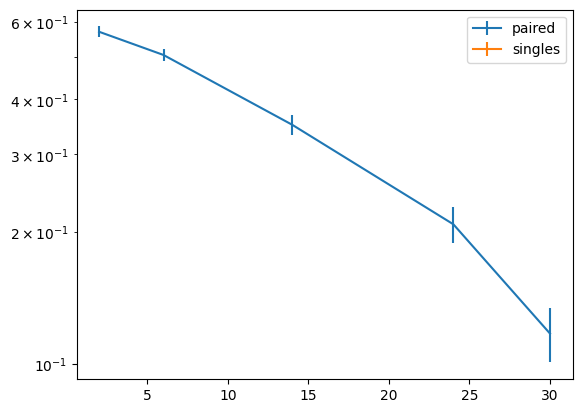

In [35]:
# For Mutual Information metrics
qa = QuantumAwesomeness(exp.backend.coupling_map)
mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [
    [[] for _ in range(len(lengths))] for _ in range(2)
]  # 'c.f. range(2) for paired' and 'singles'
yerrs = [[], [], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % len(lengths)].append(m)
    for j in range(len(lengths)):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

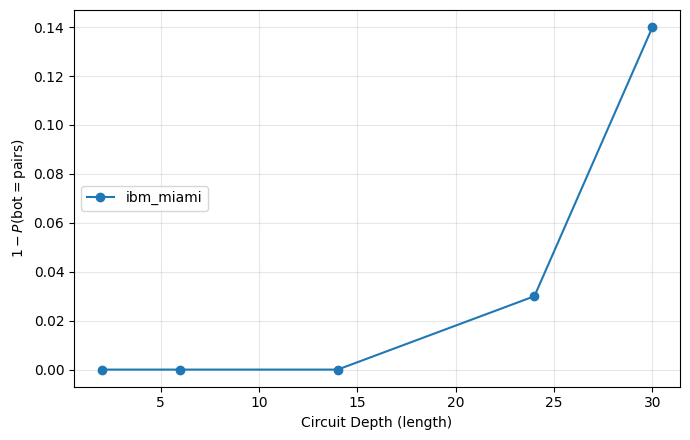

In [36]:
# Plot 1: P(bot=pairs) vs depth
plt.figure(figsize=(7, 4.5))
plt.plot(
    results_hw["miami"]["lengths"],
    [1 - p for p in results_hw["miami"]["p_bot_pairs"]],
    marker="o",
    linestyle="-",
    label="ibm_miami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"$1 - P(\mathrm{bot} = \mathrm{pairs})$")
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: P(bot=pairs) vs depth
plt.figure(figsize=(7, 4.5))
plt.plot(
    results_hw["miami"]["lengths"],
    [1 - p for p in results_hw["miami"]["p_mode_topo"]],  # or 'p_mode_topo'
    marker="o",
    linestyle="-",
    label="ibm_miami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"$1 - P(\mathrm{bot} = \mathrm{topo})$")  # or 'topo'
plt.grid(True, alpha=0.3)
plt.legend(loc="center right", frameon=True)
plt.tight_layout()
plt.show()